# Music & Mental Health — Exploratory Data Analysis
**CDC UNC 2026 Datathon** · dataset: `mxmh_survey_results.csv` (736 respondents × 33 columns)

Stack: **pandas** for wrangling, **seaborn/matplotlib** for static charts, **plotly** for a couple of interactive ones
(hover, zoom — handy when presenting).

Sections
1. Setup & load
2. Data quality & cleaning
3. Who answered the survey?
4. Mental-health scores
5. Genres: favorites and listening habits
6. Relationships: genre, listening, and mental health
7. Self-reported music effects
8. Interactive views (plotly)
9. Takeaways & next questions

## 1. Setup & load

In [24]:
# !pip install pandas seaborn matplotlib plotly   # uncomment in Colab if needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

CSV_PATH = "data/mxmh_survey_results.csv"   # change if your file lives elsewhere

# ---- shared style: one validated, colorblind-safe palette for every chart ----
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
CAT = [BLUE, ORANGE, AQUA]                    # categorical, fixed order (max 3 per chart)
SEQ = sns.light_palette("#184f95", as_cmap=True)             # sequential: one hue, light -> dark
DIV = sns.blend_palette(["#1c5cab", "#f0efec", "#c9302f"], as_cmap=True)  # diverging: blue - gray - red
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"

sns.set_theme(style="whitegrid", rc={
    "figure.dpi": 110, "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
pd.set_option("display.max_columns", 40)

df_raw = pd.read_csv(CSV_PATH)
print(df_raw.shape)
df_raw.head()

(736, 33)


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


## 2. Data quality & cleaning

In [25]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    str    
 12  Frequency [Country]           736 non-null    str    
 13  Frequency [EDM] 

In [26]:
missing = df_raw.isna().sum()
missing[missing > 0].sort_values(ascending=False).to_frame("n_missing").assign(
    pct=lambda t: (t.n_missing / len(df_raw) * 100).round(1))

,n_missing,pct
BPM,107,14.5
Music effects,8,1.1
Instrumentalist,4,0.5
Foreign languages,4,0.5
While working,3,0.4
Age,1,0.1
Primary streaming service,1,0.1
Composer,1,0.1


In [27]:
# BPM has impossible values (e.g. 999,999,999) — look at the tails before cleaning
print(df_raw["BPM"].describe())
print("Values outside 40-250:", sorted(df_raw.loc[~df_raw["BPM"].between(40, 250) & df_raw["BPM"].notna(), "BPM"].tolist()))

count    6.290000e+02
mean     1.589948e+06
std      3.987261e+07
min      0.000000e+00
25%      1.000000e+02
50%      1.200000e+02
75%      1.440000e+02
max      1.000000e+09
Name: BPM, dtype: float64
Values outside 40-250: [0.0, 0.0, 0.0, 4.0, 8.0, 20.0, 624.0, 999999999.0]


In [28]:
FREQ_ORDER = ["Never", "Rarely", "Sometimes", "Very frequently"]
FREQ_MAP = {k: i for i, k in enumerate(FREQ_ORDER)}          # ordinal 0..3
MH = ["Anxiety", "Depression", "Insomnia", "OCD"]

df = df_raw.copy()
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.drop(columns=["Permissions"])                          # constant column ("I understand.")
df.loc[~df["BPM"].between(40, 250), "BPM"] = np.nan              # implausible tempos -> missing
df = df[df["Hours per day"] <= 24]

freq_cols = [c for c in df.columns if c.startswith("Frequency [")]
genres = [c[len("Frequency ["):-1] for c in freq_cols]
for c in freq_cols:
    df[c] = pd.Categorical(df[c], categories=FREQ_ORDER, ordered=True)
    df[c.replace("Frequency", "Freq#")] = df[c].map(FREQ_MAP).astype(float)   # numeric twin for correlations

for c in ["While working", "Instrumentalist", "Composer", "Exploratory", "Foreign languages"]:
    df[c] = df[c].map({"Yes": True, "No": False})

df["Age group"] = pd.cut(df["Age"], [0, 17, 24, 34, 49, 120], labels=["<18", "18-24", "25-34", "35-49", "50+"])
df["MH total"] = df[MH].sum(axis=1)                             # crude 0-40 composite
print(df.shape)
df[MH + ["Age", "Hours per day", "BPM"]].describe().round(2)

(736, 50)


,Anxiety,Depression,Insomnia,OCD,Age,Hours per day,BPM
count,736.00,736.00,736.00,736.00,735.00,736.00,621.00
mean,5.84,4.80,3.74,2.64,25.21,3.57,123.76
std,2.79,3.03,3.09,2.84,12.05,3.03,32.03
min,0.00,0.00,0.00,0.00,10.00,0.00,40.00
25%,4.00,2.00,1.00,0.00,18.00,2.00,100.00
50%,6.00,5.00,3.00,2.00,21.00,3.00,120.00
75%,8.00,7.00,6.00,5.00,28.00,5.00,144.00
max,10.00,10.00,10.00,10.00,89.00,24.00,220.00


## 3. Who answered the survey?

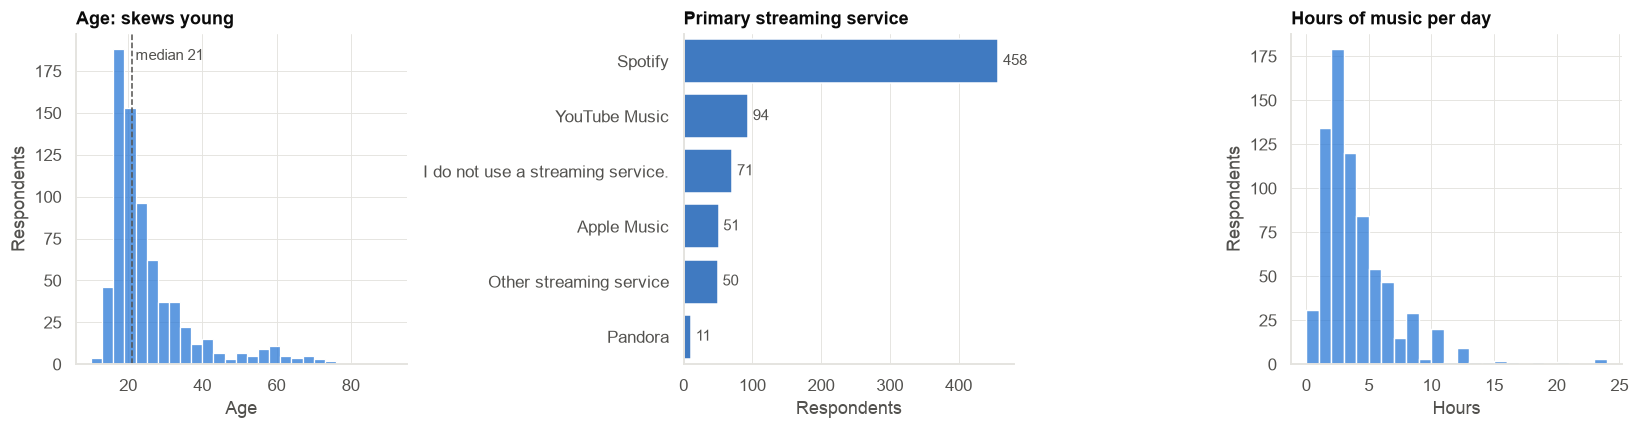

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["Age"], bins=range(10, 92, 3), color=BLUE, edgecolor="white", ax=axes[0])
axes[0].axvline(df["Age"].median(), color=INK2, ls="--", lw=1)
axes[0].text(df["Age"].median() + 1, axes[0].get_ylim()[1] * 0.92, f"median {df['Age'].median():.0f}", color=INK2)
axes[0].set(title="Age: skews young", xlabel="Age", ylabel="Respondents")

svc = df["Primary streaming service"].value_counts()
sns.barplot(x=svc.values, y=svc.index, color=BLUE, ax=axes[1])
axes[1].bar_label(axes[1].containers[0], padding=3, color=INK2)
axes[1].set(title="Primary streaming service", xlabel="Respondents", ylabel="")

sns.histplot(df["Hours per day"], bins=range(0, 25), color=BLUE, edgecolor="white", ax=axes[2])
axes[2].set(title="Hours of music per day", xlabel="Hours", ylabel="Respondents")
plt.tight_layout(); plt.show()

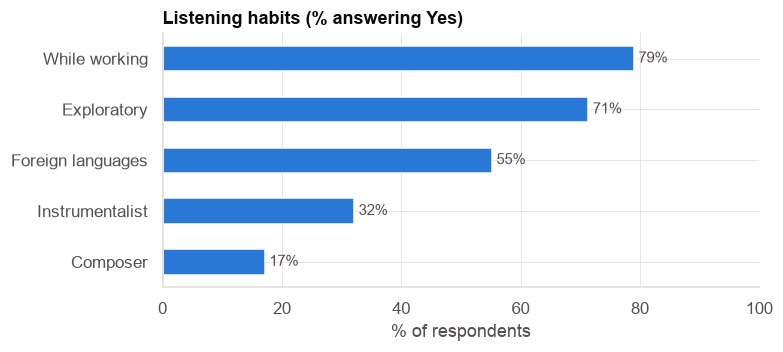

In [30]:
# Yes/No habits at a glance (% of respondents answering Yes)
yn = ["While working", "Exploratory", "Foreign languages", "Instrumentalist", "Composer"]
share = (df[yn].mean() * 100).sort_values()
ax = share.plot.barh(color=BLUE, figsize=(7, 3))
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color=INK2)
ax.set(title="Listening habits (% answering Yes)", xlabel="% of respondents", xlim=(0, 100))
plt.show()

## 4. Mental-health scores (self-rated 0–10)

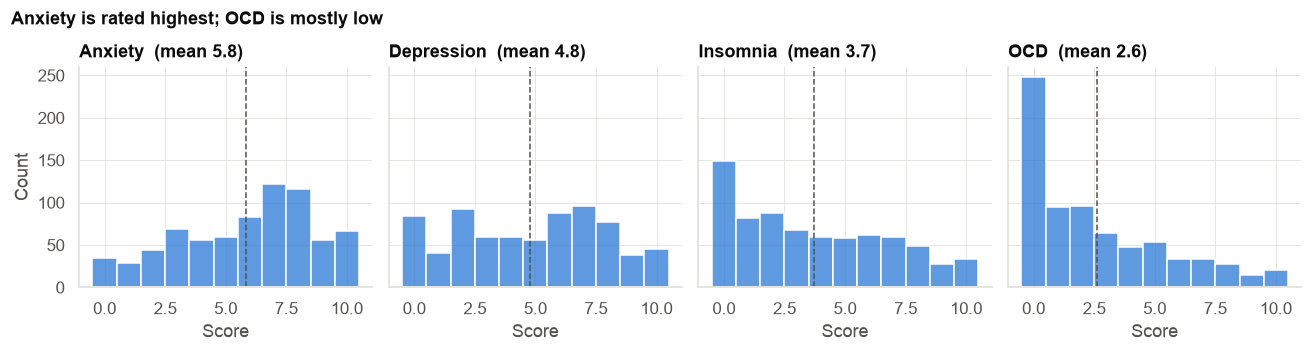

In [31]:
long = df.melt(value_vars=MH, var_name="Condition", value_name="Score")
g = sns.displot(long, x="Score", col="Condition", col_wrap=4, bins=np.arange(-0.5, 11, 1),
                color=BLUE, edgecolor="white", height=3, aspect=1)
for ax, c in zip(g.axes.flat, MH):
    m = df[c].mean()
    ax.axvline(m, color=INK2, ls="--", lw=1); ax.set_title(f"{c}  (mean {m:.1f})")
g.fig.suptitle("Anxiety is rated highest; OCD is mostly low", x=0.01, ha="left", y=1.05, fontweight="bold")
plt.show()

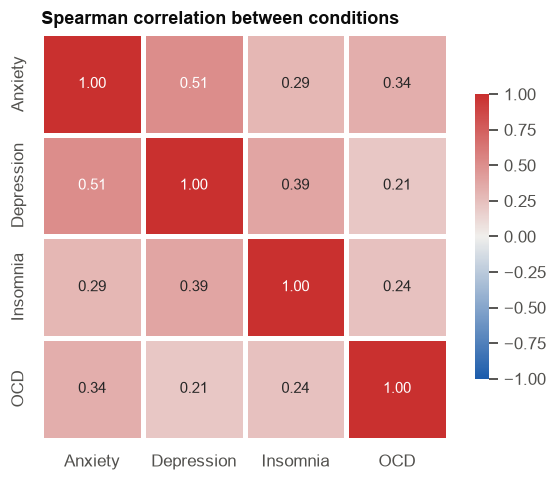

In [32]:
# How the four conditions move together
corr = df[MH].corr(method="spearman")
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIV, vmin=-1, vmax=1, square=True,
                 linewidths=2, linecolor="white", cbar_kws={"shrink": .7})
ax.set_title("Spearman correlation between conditions"); plt.show()

{'<18': 153, '18-24': 334, '25-34': 144, '35-49': 56, '50+': 48}


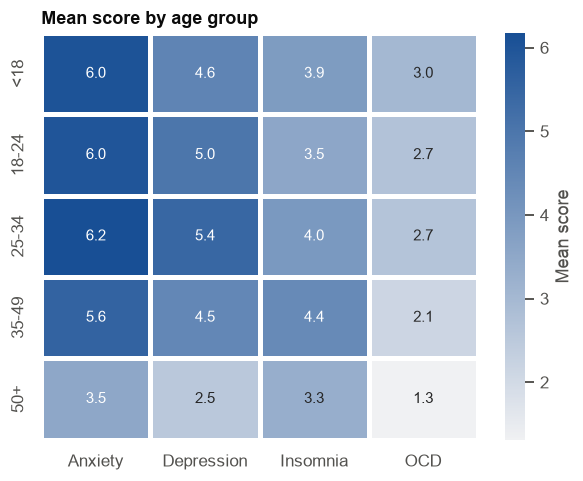

In [33]:
# Do scores differ by age group?
ag = df.groupby("Age group", observed=True)[MH].mean()
ax = sns.heatmap(ag, annot=True, fmt=".1f", cmap=SEQ, linewidths=2, linecolor="white",
                 cbar_kws={"label": "Mean score"})
ax.set_title("Mean score by age group"); ax.set_ylabel("")
print(df["Age group"].value_counts().sort_index().to_dict())   # check group sizes before reading too much into it
plt.show()

## 5. Genres: favorites and listening habits

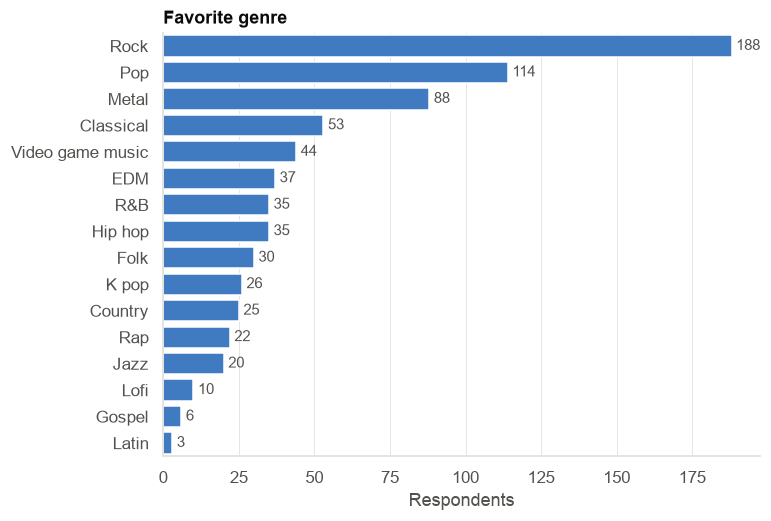

In [34]:
fav = df["Fav genre"].value_counts()
ax = sns.barplot(x=fav.values, y=fav.index, color=BLUE)
ax.bar_label(ax.containers[0], padding=3, color=INK2)
ax.set(title="Favorite genre", xlabel="Respondents", ylabel="")
plt.gcf().set_size_inches(7, 5); plt.show()

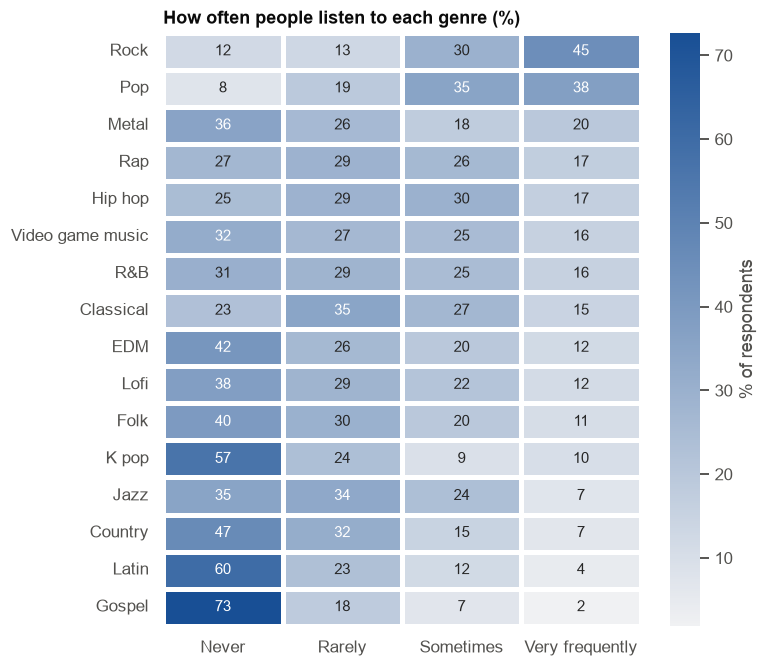

In [35]:
# Share of respondents listening 'Very frequently' / 'Sometimes' / ... to each genre
freq_share = pd.DataFrame({g: df[f"Frequency [{g}]"].value_counts(normalize=True) for g in genres}).T[FREQ_ORDER] * 100
freq_share = freq_share.sort_values("Very frequently", ascending=False)
ax = sns.heatmap(freq_share, annot=True, fmt=".0f", cmap=SEQ, linewidths=2, linecolor="white",
                 cbar_kws={"label": "% of respondents"})
ax.set(title="How often people listen to each genre (%)", xlabel="", ylabel="")
plt.gcf().set_size_inches(7, 7); plt.show()

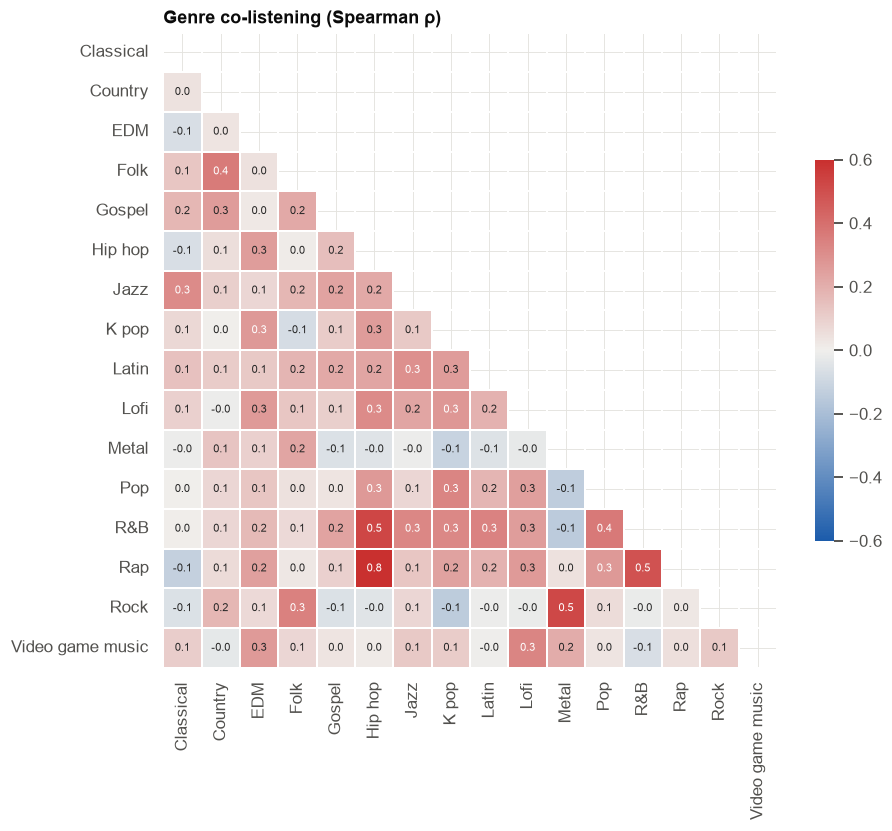

In [36]:
# Which genres get listened to together? (Spearman on the 0-3 frequency scores)
fnum = df[[f"Freq# [{g}]" for g in genres]].rename(columns=lambda c: c[7:-1])
co = fnum.corr(method="spearman")
mask = np.triu(np.ones_like(co, dtype=bool))
ax = sns.heatmap(co, mask=mask, cmap=DIV, vmin=-0.6, vmax=0.6, annot=True, fmt=".1f",
                 annot_kws={"size": 7}, linewidths=1, linecolor="white", cbar_kws={"shrink": .6})
ax.set_title("Genre co-listening (Spearman ρ)")
plt.gcf().set_size_inches(9, 7.5); plt.show()

## 6. Relationships: genre, listening, and mental health

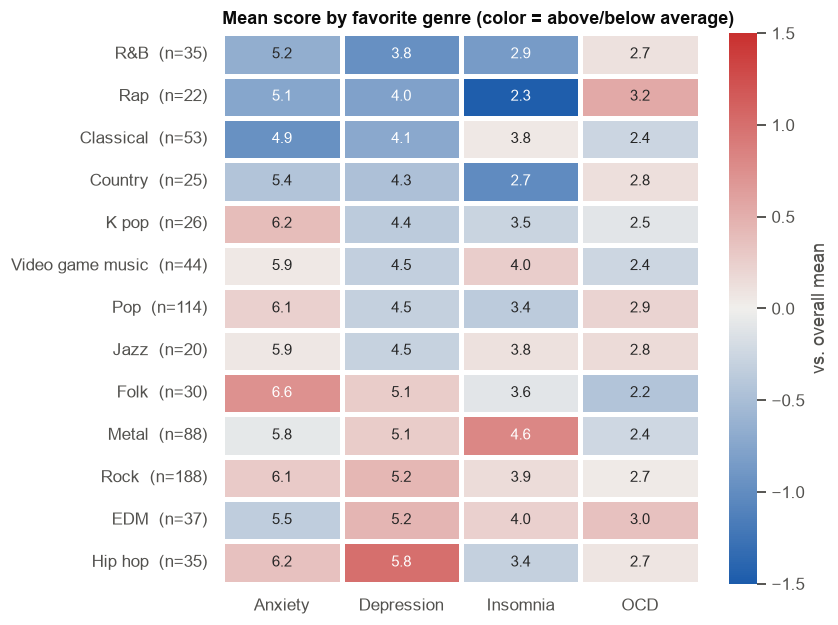

In [37]:
# Mean score by favorite genre, shown as difference from the overall mean (genres with n >= 20)
counts = df["Fav genre"].value_counts()
keep = counts[counts >= 20].index
by_genre = df[df["Fav genre"].isin(keep)].groupby("Fav genre")[MH].mean()
diff = (by_genre - df[MH].mean()).sort_values("Depression")
ax = sns.heatmap(diff, annot=by_genre.loc[diff.index].round(1), fmt="", cmap=DIV, center=0,
                 vmin=-1.5, vmax=1.5, linewidths=2, linecolor="white",
                 cbar_kws={"label": "vs. overall mean"})
ax.set_yticklabels([f"{g}  (n={counts[g]})" for g in diff.index], rotation=0)
ax.set(title="Mean score by favorite genre (color = above/below average)", xlabel="", ylabel="")
plt.gcf().set_size_inches(7, 6.5); plt.show()

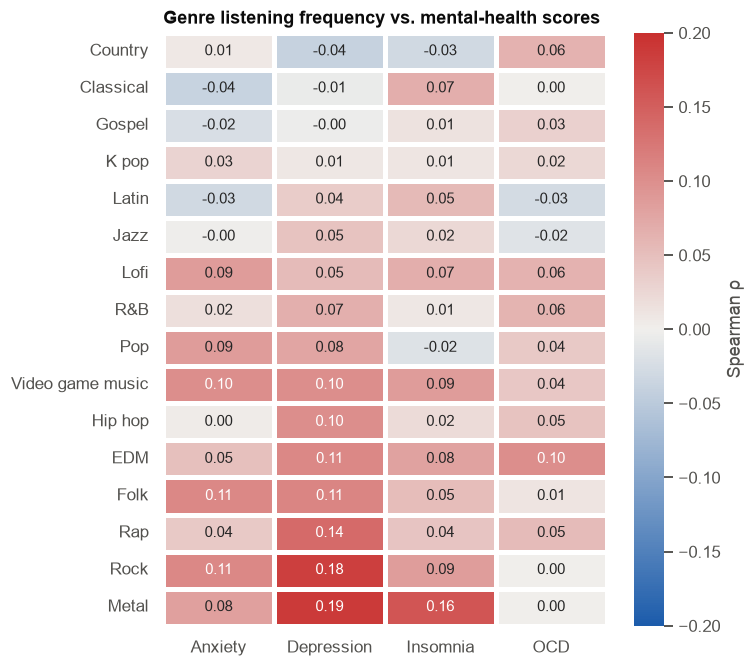

In [38]:
# Listening frequency of each genre vs each condition (Spearman ρ). Small effects - read as hints, not findings.
rho = pd.DataFrame({m: fnum.corrwith(df[m], method="spearman") for m in MH}).sort_values("Depression")
ax = sns.heatmap(rho, annot=True, fmt=".2f", cmap=DIV, center=0, vmin=-0.2, vmax=0.2,
                 linewidths=2, linecolor="white", cbar_kws={"label": "Spearman ρ"})
ax.set(title="Genre listening frequency vs. mental-health scores", ylabel="")
plt.gcf().set_size_inches(6.5, 7); plt.show()

{'≤1': 148, '1-2': 190, '2-3': 126, '3-5': 138, '5-8': 91, '8+': 43}


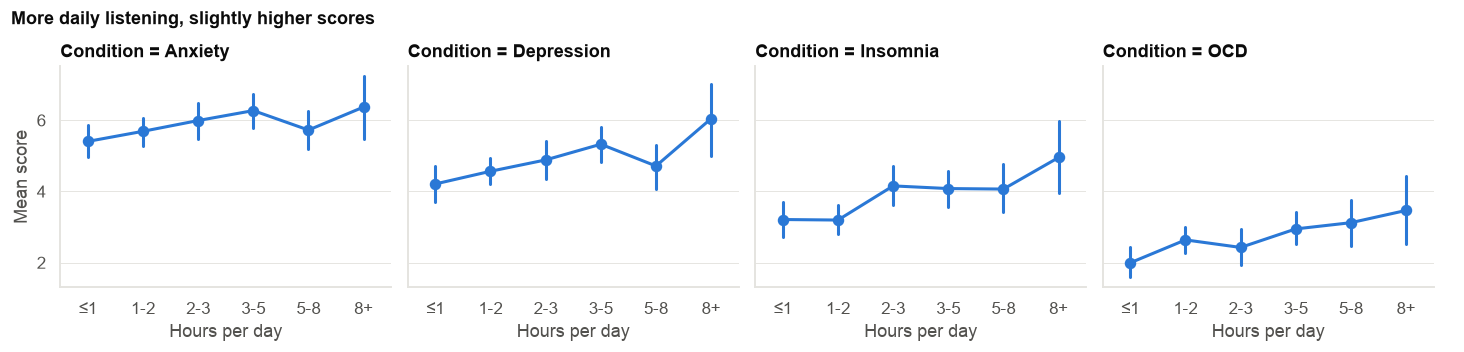

In [39]:
# Hours per day vs scores: binned means with 95% CI (raw scatter is too overplotted to read)
df["Hours bin"] = pd.cut(df["Hours per day"], [-0.1, 1, 2, 3, 5, 8, 24], labels=["≤1", "1-2", "2-3", "3-5", "5-8", "8+"])
hb = df.melt(id_vars="Hours bin", value_vars=MH, var_name="Condition", value_name="Score")
g = sns.catplot(hb, x="Hours bin", y="Score", col="Condition", kind="point", color=BLUE,
                errorbar=("ci", 95), height=3, aspect=1.1, col_wrap=4, markersize=6, linewidth=2)
g.set_axis_labels("Hours per day", "Mean score")
g.fig.suptitle("More daily listening, slightly higher scores", x=0.01, ha="left", y=1.05, fontweight="bold")
print(df["Hours bin"].value_counts().sort_index().to_dict())
plt.show()

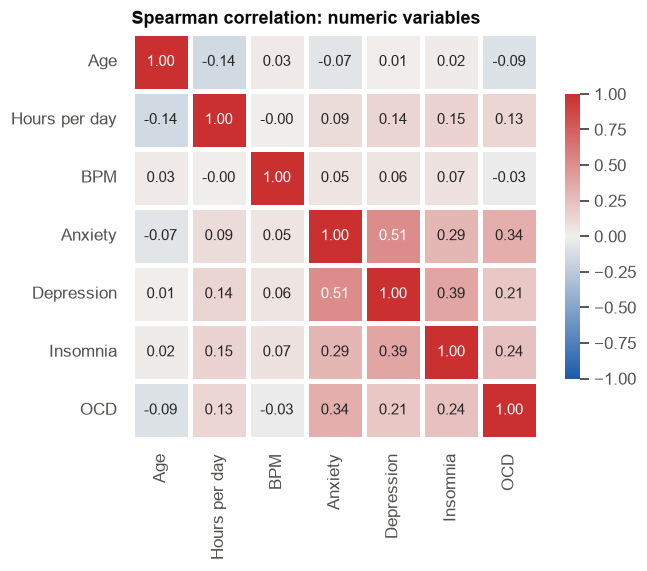

In [40]:
# Numeric drivers overview
num = ["Age", "Hours per day", "BPM"] + MH
ax = sns.heatmap(df[num].corr(method="spearman"), annot=True, fmt=".2f", cmap=DIV, vmin=-1, vmax=1,
                 square=True, linewidths=2, linecolor="white", cbar_kws={"shrink": .7})
ax.set_title("Spearman correlation: numeric variables"); plt.show()

## 7. Self-reported music effects

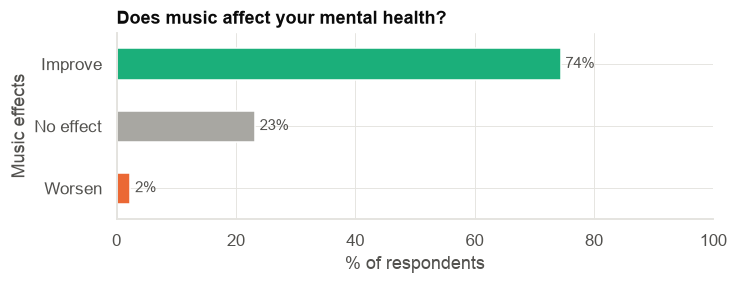

In [41]:
eff = df["Music effects"].value_counts(normalize=True).reindex(["Improve", "No effect", "Worsen"]) * 100
ax = eff.plot.barh(color=[AQUA, "#a8a7a2", ORANGE], figsize=(7, 2.2))
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color=INK2); ax.invert_yaxis()
ax.set(title="Does music affect your mental health?", xlabel="% of respondents", xlim=(0, 100)); plt.show()

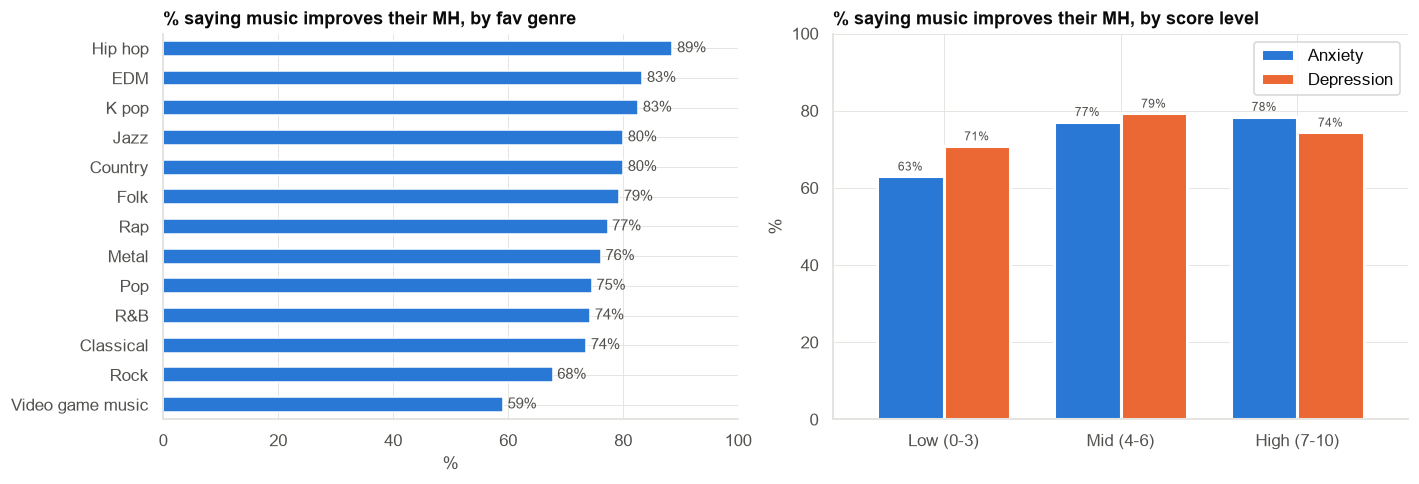

In [42]:
# Share saying music 'Improves' their mental health, by favorite genre (n >= 20) and by score level
imp = (df[df["Fav genre"].isin(keep)].groupby("Fav genre")["Music effects"]
       .apply(lambda s: (s.dropna() == "Improve").mean() * 100).sort_values())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
imp.plot.barh(color=BLUE, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt="%.0f%%", padding=3, color=INK2)
axes[0].set(title="% saying music improves their MH, by fav genre", xlabel="%", ylabel="", xlim=(0, 100))

df["Anxiety level"] = pd.cut(df["Anxiety"], [-1, 3, 6, 10], labels=["Low (0-3)", "Mid (4-6)", "High (7-10)"])
df["Depression level"] = pd.cut(df["Depression"], [-1, 3, 6, 10], labels=["Low (0-3)", "Mid (4-6)", "High (7-10)"])
lv = pd.DataFrame({
    "Anxiety": df.groupby("Anxiety level", observed=True)["Music effects"].apply(lambda s: (s.dropna() == "Improve").mean() * 100),
    "Depression": df.groupby("Depression level", observed=True)["Music effects"].apply(lambda s: (s.dropna() == "Improve").mean() * 100),
})
lv.plot.bar(color=[BLUE, ORANGE], ax=axes[1], rot=0, width=0.75, edgecolor="white", linewidth=2)
for cont in axes[1].containers: axes[1].bar_label(cont, fmt="%.0f%%", padding=2, color=INK2, fontsize=8)
axes[1].set(title="% saying music improves their MH, by score level", xlabel="", ylabel="%", ylim=(0, 100))
plt.tight_layout(); plt.show()

## 8. Interactive views (plotly)
Hover for exact values, click legend entries to toggle, drag to zoom.

In [43]:
px.defaults.template = "plotly_white"
fig = px.box(df[df["Fav genre"].isin(keep)].melt(id_vars="Fav genre", value_vars=MH, var_name="Condition", value_name="Score"),
             x="Fav genre", y="Score", color="Condition", points=False,
             color_discrete_sequence=[BLUE, ORANGE, AQUA, YELLOW],
             title="Score distributions by favorite genre (n ≥ 20)")
fig.update_layout(height=450, xaxis_title="", legend_title="")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
fig = px.scatter(df, x="Age", y="Hours per day", color="Music effects", opacity=0.6,
                 color_discrete_map={"Improve": BLUE, "No effect": "#a8a7a2", "Worsen": ORANGE},
                 hover_data=["Fav genre"] + MH, title="Age vs. daily listening (hover for details)")
fig.update_traces(marker=dict(size=8, line=dict(width=1, color="white")))
fig.update_layout(height=450, legend_title="")
fig.show()

NameError: name 'px' is not defined

## 9. Takeaways & next questions
*(Fill in after running — the numbers above are what to cite.)*

**Caveats to keep in mind**
- Convenience sample, skewed young and toward Spotify/Rock/Pop — not representative.
- Scores are self-rated 0–10, not clinical measures; correlations are small and **not causal**.
- Some genres have tiny n (Latin, Gospel, Lofi) — we filtered to n ≥ 20 for genre comparisons.

**Good next steps for the datathon**
- Test genre differences formally (Kruskal-Wallis + post-hoc) instead of eyeballing means.
- Model `Music effects == "Improve"` with logistic regression (hours, age, exploratory, genre frequencies, scores).
- Cluster respondents on the 16 genre-frequency columns (k-means / PCA) and profile clusters by mental health.
- For a quick automated report, try `ydata-profiling`: `ProfileReport(df).to_file("report.html")`.